# Gantt Chart

A gantt chart shows a schedule: one bar per task from its start to its end over a date axis, so a plan answers *what happens when, what is late, and what waits on what*. This guide shows how to create gantt charts with the [datachart.charts.GanttChart](../../../references/charts/#datachart.charts.GanttChart) function, starting with the basics and building up to worked examples on realistic schedules.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-gantt-chart), which maps common tasks to the parameter or style attribute that does the job.

In [1]:
from datachart.charts import GanttChart

## Basics

The examples in this guide share one schedule: building a family house, from the architect's drawings on 1 March 2025 to the handover at the end of October. The schedule is illustrative, written out in a hidden cell with the shape such builds take: drawings and a permit first, then groundwork, the structure, the services, and the finishes. It has a story in it. Rain held up the foundations for two weeks, and every task after them slipped by the same two weeks, while the kitchen, ordered early, kept its dates. `house` holds the task records as the site manager sees them on Monday 16 June 2025, `TODAY`; `baseline` holds the plan as it was signed, before the rain. The customizations below ask the questions a site manager asks of such a plan: what is next, what is late, what blocks what, and how far along the build is.

In [2]:
from datetime import date, timedelta

TODAY = date(2025, 6, 16)
RAIN_DELAY = timedelta(weeks=2)

# an illustrative house build, as forecast on TODAY
house = [
    {"task": "Architect drawings", "start": date(2025, 3, 1), "end": date(2025, 3, 28),
     "group": "Design", "progress": 1.0},
    {"task": "Permit review", "start": date(2025, 3, 31), "end": date(2025, 5, 2),
     "group": "Design", "progress": 1.0, "depends_on": ["Architect drawings"]},
    {"task": "Permit granted", "start": date(2025, 5, 2), "end": date(2025, 5, 2),
     "group": "Design", "depends_on": ["Permit review"]},
    {"task": "Site clearing", "start": date(2025, 5, 5), "end": date(2025, 5, 16),
     "group": "Groundwork", "progress": 1.0, "depends_on": ["Permit granted"]},
    {"task": "Foundations", "start": date(2025, 5, 19), "end": date(2025, 6, 20),
     "group": "Groundwork", "progress": 0.8, "depends_on": ["Site clearing"]},
    {"task": "Framing", "start": date(2025, 6, 23), "end": date(2025, 8, 1),
     "group": "Structure", "depends_on": ["Foundations"]},
    {"task": "Roofing", "start": date(2025, 7, 21), "end": date(2025, 8, 15),
     "group": "Structure", "depends_on": ["Framing"]},
    {"task": "Windows and doors", "start": date(2025, 8, 4), "end": date(2025, 8, 22),
     "group": "Structure", "depends_on": ["Framing"]},
    {"task": "Weathertight", "start": date(2025, 8, 22), "end": date(2025, 8, 22),
     "group": "Structure", "depends_on": ["Roofing", "Windows and doors"]},
    {"task": "Plumbing", "start": date(2025, 8, 4), "end": date(2025, 8, 29),
     "group": "Services", "depends_on": ["Framing"]},
    {"task": "Wiring", "start": date(2025, 8, 11), "end": date(2025, 9, 5),
     "group": "Services", "depends_on": ["Framing"]},
    {"task": "Kitchen order", "start": date(2025, 6, 2), "end": date(2025, 8, 29),
     "group": "Finishes", "progress": 0.2},
    {"task": "Drywall", "start": date(2025, 9, 8), "end": date(2025, 9, 26),
     "group": "Finishes", "depends_on": ["Weathertight", "Plumbing", "Wiring"]},
    {"task": "Kitchen fitting", "start": date(2025, 9, 29), "end": date(2025, 10, 10),
     "group": "Finishes", "depends_on": ["Drywall", "Kitchen order"]},
    {"task": "Painting and floors", "start": date(2025, 9, 29), "end": date(2025, 10, 24),
     "group": "Finishes", "depends_on": ["Drywall"]},
    {"task": "Handover", "start": date(2025, 10, 29), "end": date(2025, 10, 29),
     "group": "Finishes", "depends_on": ["Kitchen fitting", "Painting and floors"]},
]

# the tasks the rain pushed back, and the plan as signed before it
FOUNDATIONS = house[4]
SLIPPED = {r["task"] for r in house if r["start"] > FOUNDATIONS["start"] and r["task"] != "Kitchen order"}
baseline = []
for r in house:
    planned = {k: v for k, v in r.items() if k != "progress"}
    if r["task"] == "Foundations":
        planned["end"] = r["end"] - RAIN_DELAY
    elif r["task"] in SLIPPED:
        planned["start"] = r["start"] - RAIN_DELAY
        planned["end"] = r["end"] - RAIN_DELAY
    baseline.append(planned)

# the chain of tasks with no slack: a day lost on any of them moves the handover
CRITICAL_PATH = {
    "Architect drawings", "Permit review", "Permit granted", "Site clearing", "Foundations",
    "Framing", "Roofing", "Weathertight", "Drywall", "Painting and floors", "Handover",
}
CONTRACT_DATE = date(2025, 10, 17)

Each task record is a dictionary. `task` names the task and labels its row, and `start` and `end` are temporal objects (`datetime.date` here; `datetime.datetime`, `numpy.datetime64` and pandas `Timestamp` work too, while date strings are never parsed). The other keys are optional: the `group` the task belongs to, the `progress` done as a fraction, the tasks it `depends_on`, and its own `emphasis`. The foundations record carries all but the last:

In [3]:
house[4]

{'task': 'Foundations',
 'start': datetime.date(2025, 5, 19),
 'end': datetime.date(2025, 6, 20),
 'group': 'Groundwork',
 'progress': 0.8,
 'depends_on': ['Site clearing']}

**Basic example.** Only the `data` argument is required. Every task is a bar from its start to its end, one row per task in input order with the first at the top, and the date ticks step from the first start to the last end, in whole months here. The groups color the bars and fill the legend, a `progress` fraction fills part of a bar with a darker inner bar, and a task that ends when it starts (the permit, the weathertight shell, the handover) is a milestone marker:

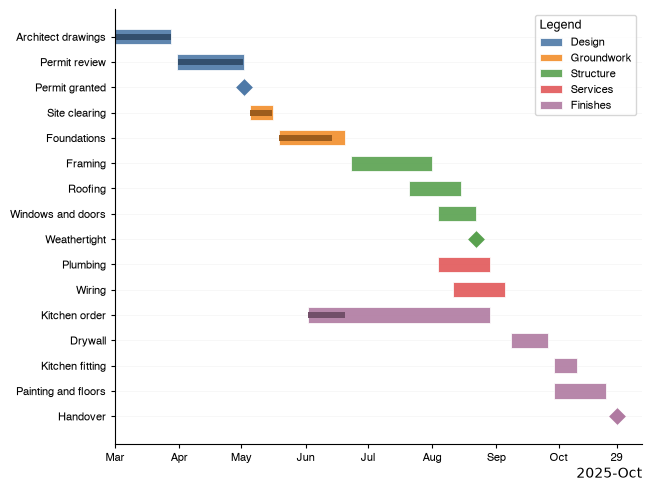

In [4]:
GanttChart(
    # add the data to the chart
    data=house
).show()

## Customizing the Gantt Chart

Every customization is either a keyword argument of `GanttChart`, a key of the task records, or a `plot_gantt_*` (or `plot_bar_*`) attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                    | Use                                                                  | See |
| :-------------------------------------------- | :------------------------------------------------------------------- | :-- |
| add a title and axis labels                   | `title`, `xlabel`, `ylabel`, `ytickrotate`                           | [Title and axis labels](#title-and-axis-labels) |
| resize the figure or show grid lines          | `figsize`, `show_grid`                                               | [Figure size and grid](#figure-size-and-grid) |
| zoom to a date window                         | `xmin`, `xmax`                                                       | [Date axis](#date-axis) |
| change or rotate the date labels              | `xticks_format`, `xtickrotate`                                       | [Date axis](#date-axis) |
| divide the date axis into weeks or months     | `period`                                                             | [Periods](#periods) |
| order the rows by start or by group           | `sort`, `sort_by`                                                    | [Row order](#row-order) |
| color the tasks by group, place the legend    | the `"group"` key, `show_legend`, `legend`                           | [Groups and legend](#groups-and-legend) |
| give each group a header row and summary bar  | `show_group_headers`                                                 | [Group headers](#group-headers) |
| mark a milestone                              | a task with `end` equal to `start`                                   | [Milestones](#milestones) |
| show how far along each task is               | the `"progress"` key, `show_values`, `value_format`                  | [Progress and value labels](#progress-and-value-labels) |
| label each bar with its duration              | `show_values`, `value_format`                                        | [Progress and value labels](#progress-and-value-labels) |
| draw what blocks what                         | the `"depends_on"` key, `show_dependencies`                          | [Dependencies](#dependencies) |
| choose where the arrows enter a task          | `style={"plot_gantt_dependency_entry": ...}`                         | [Dependencies](#dependencies) |
| mark today                                    | `show_today`, `today`, `today_label`                                 | [Today line](#today-line) |
| mark a deadline or shade a period             | `vlines`, `vspans`                                                   | [Reference lines and bands](#reference-lines-and-bands) |
| put a note on the chart                       | `texts`                                                              | [Text annotations](#text-annotations) |
| change the bar, progress, or arrow look       | `style={"plot_gantt_bar_height": ..., ...}`                          | [Gantt style](#gantt-style) |
| highlight some tasks, mute the rest           | the `"emphasis"` key, `emphasis_rule`                                | [Emphasis](#emphasis) |
| compare several schedules                     | `data` as a list of lists, `subtitle`, `max_cols`, `emphasis`        | [Multiple Gantt Charts](#multiple-gantt-charts) |
| place a schedule beside other charts          | `Grid`                                                               | [Composing gantt charts](#composing-gantt-charts) |
| schedule by the hour, or use numpy dates      | `datetime` or `numpy.datetime64` values                              | [Other date types](#other-date-types) |
| restyle every chart at once                   | `config.set_theme`                                                   | [Themes](#themes) |
| save the chart to a file                      | `save_figure`                                                        | [Saving Figures](../../utility/saving/) guide |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `period` | [`GANTT_DATE_PERIOD`](../../../references/constants/#datachart.constants.GANTT_DATE_PERIOD) |
| `show_values` | [`GANTT_VALUE`](../../../references/constants/#datachart.constants.GANTT_VALUE) |
| `sort_by` | [`GANTT_SORT_KEY`](../../../references/constants/#datachart.constants.GANTT_SORT_KEY) |
| `style={"plot_gantt_dependency_entry": ...}` | [`GANTT_ARROW_ENTRY`](../../../references/constants/#datachart.constants.GANTT_ARROW_ENTRY) |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |
| `legend={"location": ..., "alignment": ...}` | [`LEGEND_LOCATION`](../../../references/constants/#datachart.constants.LEGEND_LOCATION), [`LEGEND_ALIGN`](../../../references/constants/#datachart.constants.LEGEND_ALIGN) |
| `show_grid` | [`SHOW_GRID`](../../../references/constants/#datachart.constants.SHOW_GRID) |
| `value_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT) |
| `sort` | [`SORT`](../../../references/constants/#datachart.constants.SORT) |
| `emphasis` | [`EMPHASIS`](../../../references/constants/#datachart.constants.EMPHASIS) |
| `xticks_format` | [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) |

The full list of style attributes is in the [datachart.typings.GanttStyleAttrs](../../../references/typings/#datachart.typings.GanttStyleAttrs) type, and the task record keys in [datachart.typings.GanttTaskAttrs](../../../references/typings/#datachart.typings.GanttTaskAttrs); the full list of parameters is in the [datachart.charts.GanttChart](../../../references/charts/#datachart.charts.GanttChart) reference.

### Title and axis labels

A plan pinned to a site office wall needs to say which project it is; `title` says it, and `xlabel` and `ylabel` name the axes. The gantt chart is always horizontal, so the axis parameters are spatial: `xlabel` names the horizontal date axis and `ylabel` the vertical task axis. Task names are read left to right, so `ytickrotate` is rarely needed; it is there for very short labels such as ticket numbers.

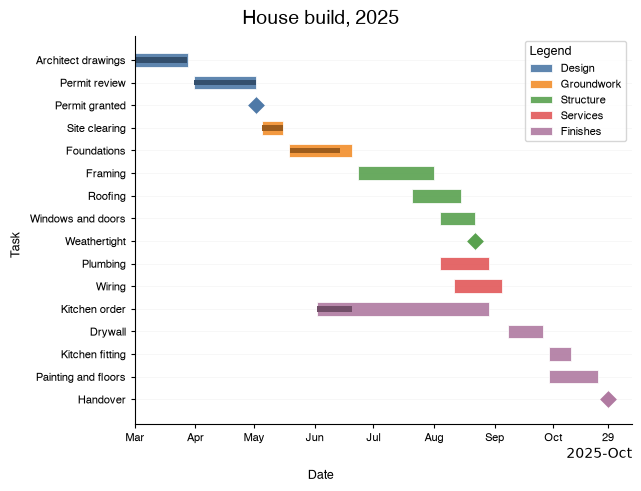

In [5]:
from datachart.constants import FIG_SIZE

GanttChart(
    data=house,
    # add the title
    title="House build, 2025",
    # add the x and y axis labels
    xlabel="Date",
    ylabel="Task",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Figure size and grid

A schedule has one row per task, so its height grows with the plan while its width is set by the page. `figsize` takes a `(width, height)` tuple in inches or one of the presets in [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE); sixteen tasks fit a full-width, medium-height figure.

Vertical grid lines carry a date down the rows, so the reader can see which tasks run in the same month. `show_grid=SHOW_GRID.X` draws them along the date axis ([SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID)); `SHOW_GRID.Y` would add a line per row, which a gantt chart rarely needs. Plumbing, wiring, and the windows share August:

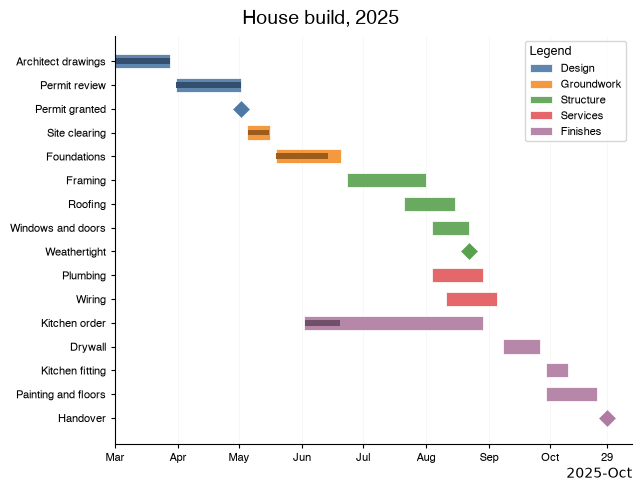

In [6]:
from datachart.constants import SHOW_GRID

GanttChart(
    data=house,
    title="House build, 2025",
    # a full-width figure, tall enough for sixteen rows
    figsize=FIG_SIZE.FULL_MEDIUM,
    # grid lines along the date axis only
    show_grid=SHOW_GRID.X,
).show()

### Date axis

The whole build spans eight months, but the site manager's question on a Monday is *what happens in the next few weeks?* `xmin` and `xmax` take temporal objects and zoom the date axis to that window; bars that run past its edges are cut at them. The default tick labels are concise; `xticks_format` prints every tick in one format, a [DATE_FORMAT](../../../references/constants/#datachart.constants.DATE_FORMAT) member or any `strftime` pattern, and `xtickrotate` tilts the labels when they crowd. Rows of tasks outside the window would stay empty, so the example first keeps the tasks that touch it (and the dependencies among them, since `depends_on` must name tasks in the chart). The eight weeks from 9 June show the foundations finishing, the framing starting on their heels, and the roofing following it.

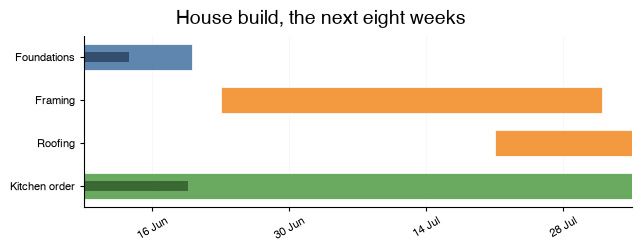

In [7]:
WINDOW = (date(2025, 6, 9), date(2025, 8, 4))


def in_window(records, first, last):
    # the tasks that touch the window, their dependencies cut to the tasks kept
    kept = [r for r in records if r["end"] > first and r["start"] < last]
    names = {r["task"] for r in kept}
    return [{**r, "depends_on": [d for d in r.get("depends_on", []) if d in names]} for r in kept]


next_weeks = in_window(house, *WINDOW)

GanttChart(
    data=next_weeks,
    title="House build, the next eight weeks",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.X,
    show_legend=False,
    # zoom to a date window
    xmin=WINDOW[0],
    xmax=WINDOW[1],
    # print every tick as day and month, tilted
    xticks_format="%d %b",
    xtickrotate=30,
).show()

### Periods

Builders count in weeks, finance counts in months or quarters, and a printed plan shows those periods as columns. `period` divides the date axis into calendar periods ([GANTT_DATE_PERIOD](../../../references/constants/#datachart.constants.GANTT_DATE_PERIOD)): `DAY`, `WEEK` (ISO weeks, starting on Monday), `MONTH`, `QUARTER`, `YEAR`, or `PROJECT_MONTH`, which numbers the months M1, M2, … from `xmin` or the earliest start. Lines mark the period edges, each period is labeled at its center, and a parent row beneath names the enclosing month (for days and weeks), year (for months and quarters), or project year. `xticks_format` sets the period labels. In ISO weeks, the window above shows that the framing takes six weeks, from week 26 to week 31:

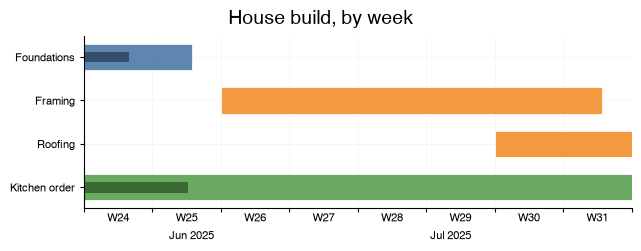

In [8]:
from datachart.constants import GANTT_DATE_PERIOD

GanttChart(
    data=next_weeks,
    title="House build, by week",
    figsize=FIG_SIZE.FULL_SHORT,
    show_legend=False,
    xmin=WINDOW[0],
    xmax=WINDOW[1],
    # ISO weeks, named under their months
    period=GANTT_DATE_PERIOD.WEEK,
).show()

Over the whole build, months are the natural column. A bank that releases the mortgage in stages reads the same plan by project month instead, since its contract counts from the first month of work:

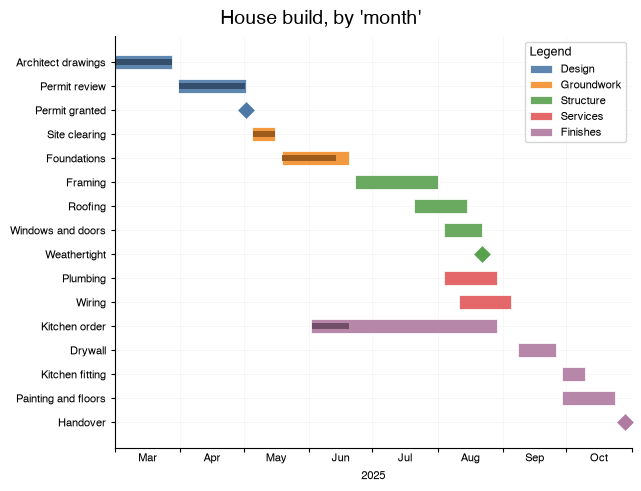

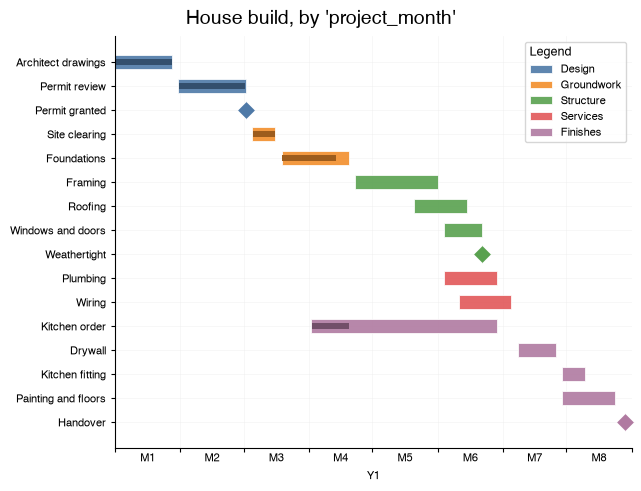

In [9]:
for period in [GANTT_DATE_PERIOD.MONTH, GANTT_DATE_PERIOD.PROJECT_MONTH]:
    GanttChart(
        data=house,
        title=f"House build, by '{period}'",
        figsize=FIG_SIZE.FULL_MEDIUM,
        # months under their year, or M1, M2, ... under project years
        period=period,
    ).show()

### Row order

The rows follow the input order, which is how the plan was written, but the question *what starts next?* wants the rows in start order. `sort` orders them ([SORT](../../../references/constants/#datachart.constants.SORT)), and `sort_by` names the key ([GANTT_SORT_KEY](../../../references/constants/#datachart.constants.GANTT_SORT_KEY)): `START`, the default, orders every row by its start date, so the chart reads as a staircase and the kitchen order, written under the finishes, moves up to June where it starts. Ties keep the input order.

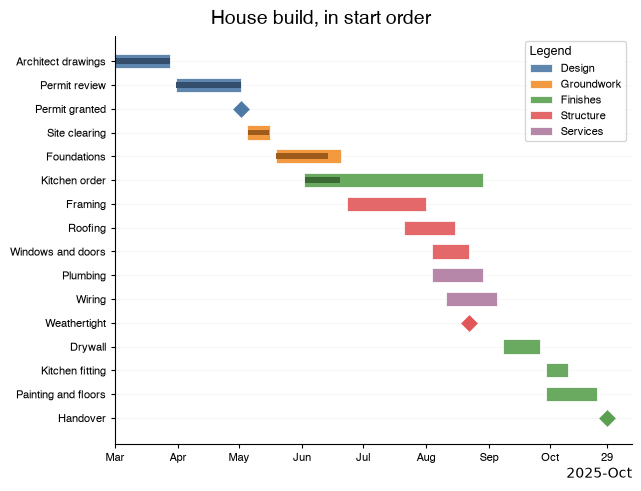

In [10]:
from datachart.constants import SORT, GANTT_SORT_KEY

GanttChart(
    data=house,
    title="House build, in start order",
    figsize=FIG_SIZE.FULL_MEDIUM,
    # earliest start at the top
    sort=SORT.ASCENDING,
    sort_by=GANTT_SORT_KEY.START,
).show()

`GANTT_SORT_KEY.GROUP` clusters the rows by group instead, the groups ordered by their earliest start and the tasks within a group by start, so each trade reads as one block. The finishes start with the kitchen order in June, so they come before the structure. `sort_by` without `sort`, or `GROUP` when no task has a `group`, raises a `ValueError`.

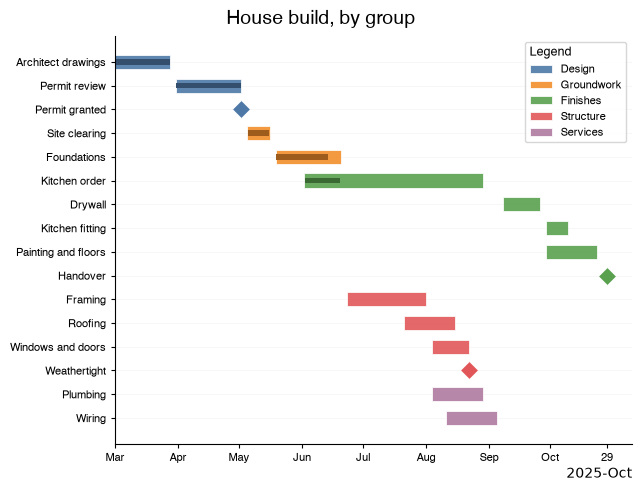

In [11]:
GanttChart(
    data=house,
    title="House build, by group",
    figsize=FIG_SIZE.FULL_MEDIUM,
    # cluster the rows by group, earliest group first
    sort=SORT.ASCENDING,
    sort_by=GANTT_SORT_KEY.GROUP,
).show()

### Groups and legend

On a building site, the question is often *which trade is on site?* A task's `group` key answers it: tasks of one group share a color from the theme's palette, in first-seen order, and the legend lists one entry per group. The legend is on whenever a task has a `group`; `show_legend=False` hides it, and `legend` gives it a `title`, a `location` from [LEGEND_LOCATION](../../../references/constants/#datachart.constants.LEGEND_LOCATION), a number of columns `ncols`, and an `alignment` from [LEGEND_ALIGN](../../../references/constants/#datachart.constants.LEGEND_ALIGN) ([LegendSettingAttrs](../../../references/typings/#datachart.typings.LegendSettingAttrs)). The schedule runs corner to corner, so the legend goes outside the axes. Tasks without a `group` draw in the chart's palette color and have no legend entry.

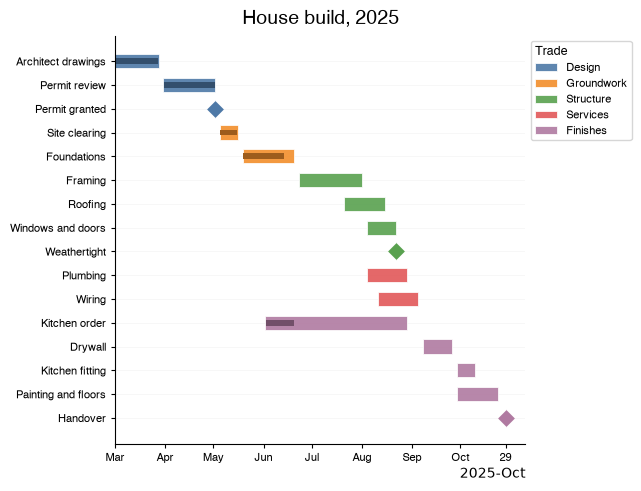

In [12]:
from datachart.constants import LEGEND_LOCATION

GanttChart(
    data=house,
    title="House build, 2025",
    figsize=FIG_SIZE.FULL_MEDIUM,
    # a titled legend outside the axes, to the right
    legend={"title": "Trade", "location": LEGEND_LOCATION.OUTSIDE_RIGHT},
).show()

### Group headers

A client does not ask when the plumbing starts; they ask *how long is each phase?* `show_group_headers=True` gives every group a header row with its name in bold and a summary bar from its first start to its last end, the group's tasks beneath it and a gap before the next group. The headers name the groups, so the legend is off unless `show_legend` turns it on. The summary bar and the gap follow the `plot_gantt_summary_height`, `plot_gantt_summary_color`, and `plot_gantt_group_gap` style attributes; without any `group`, `show_group_headers` raises a `ValueError`. The finishes phase is the longest, because it opens with the early kitchen order:

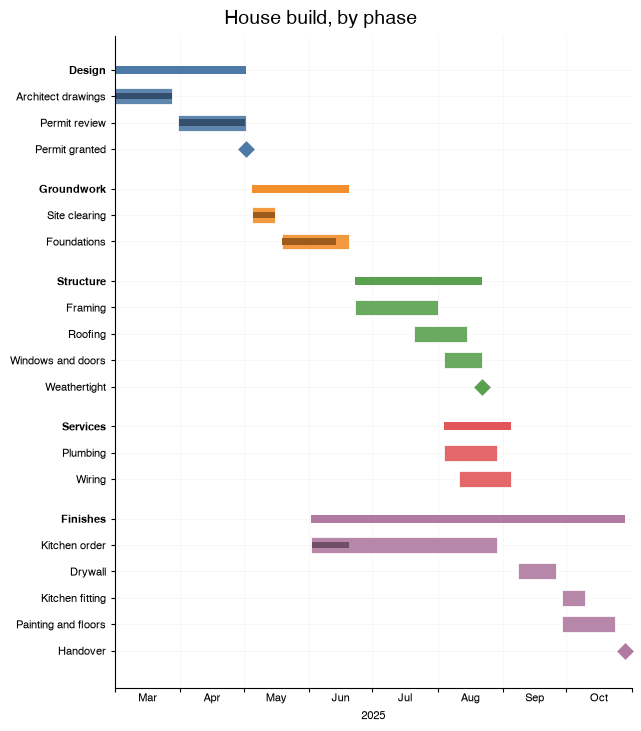

In [13]:
GanttChart(
    data=house,
    title="House build, by phase",
    # five header rows join the sixteen tasks
    figsize=FIG_SIZE.FULL_TALL,
    # a header row and a summary bar for every group
    show_group_headers=True,
    period=GANTT_DATE_PERIOD.MONTH,
).show()

### Milestones

Some events take no time but everything waits for them: the permit, the day the shell is weathertight, the handover. A task whose `end` equals its `start` is a milestone, drawn as a marker instead of a bar. Under `show_values` a milestone prints its date beside the marker, in the `xticks_format` or as day and month, since it has no duration to print; the `plot_gantt_milestone_marker` and `plot_gantt_milestone_size` style attributes set its look. `milestones` keeps only the three milestones of the build (without their dependencies, whose tasks are left out), so the chart answers *when are the key dates?*

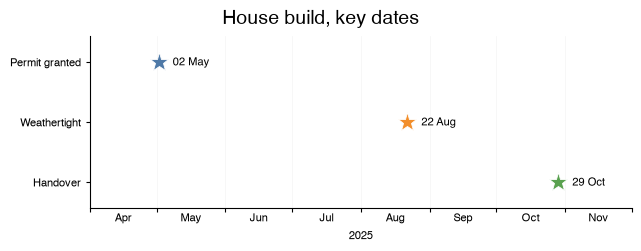

In [14]:
from datachart.constants import GANTT_VALUE

milestones = [
    {k: v for k, v in r.items() if k != "depends_on"} for r in house if r["start"] == r["end"]
]

GanttChart(
    data=milestones,
    title="House build, key dates",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.X,
    # room around the first and the last date
    xmin=date(2025, 4, 1),
    xmax=date(2025, 12, 1),
    period=GANTT_DATE_PERIOD.MONTH,
    # a milestone prints its date
    show_values=GANTT_VALUE.DURATION,
    # a larger star
    style={"plot_gantt_milestone_marker": "*", "plot_gantt_milestone_size": 14},
    show_legend=False,
).show()

### Progress and value labels

*How far along are we?* is answered by a task's `progress` key, the fraction done in `[0, 1]`, drawn as an inner bar from the task's start. `show_values` prints a label past each bar end ([GANTT_VALUE](../../../references/constants/#datachart.constants.GANTT_VALUE)): `PROGRESS` prints the progress as a percentage (a task without `progress` stays unlabeled), `DURATION` the duration in days. `value_format` formats the number, a [VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) constant or any `"{x:.1f}"` style string: it formats the progress fraction or the days. On 16 June the design and site work are done, the foundations are at 80%, and the kitchen order at 20%:

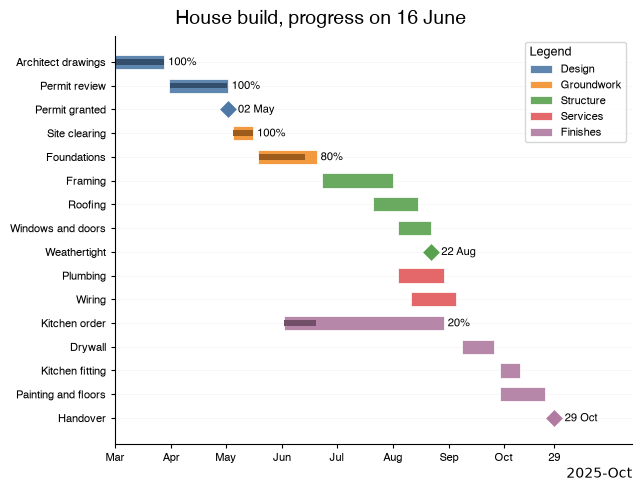

In [15]:
GanttChart(
    data=house,
    title="House build, progress on 16 June",
    figsize=FIG_SIZE.FULL_MEDIUM,
    # label each bar with its progress
    show_values=GANTT_VALUE.PROGRESS,
).show()

The durations answer a different question: *which tasks tie up the crew longest?* A duration counts the days from `start` to `end`, weekends included; `value_format` adds the unit:

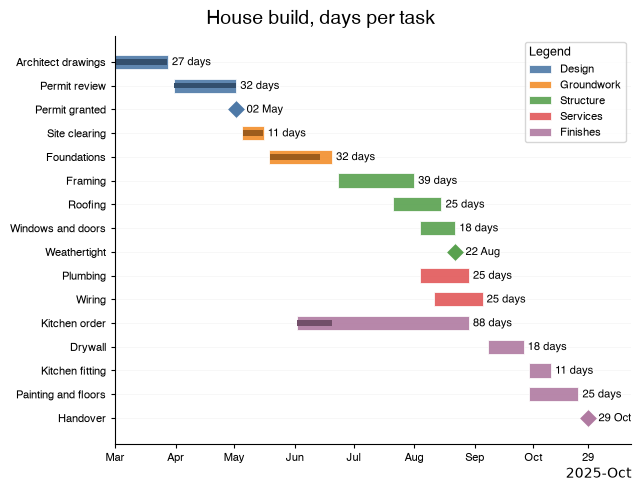

In [16]:
GanttChart(
    data=house,
    title="House build, days per task",
    figsize=FIG_SIZE.FULL_MEDIUM,
    # label each bar with its duration, in days
    show_values=GANTT_VALUE.DURATION,
    value_format="{x:.0f} days",
    # room for the labels past the last bar
    xmax=date(2025, 11, 20),
).show()

### Dependencies

The framing crew cannot start until the foundations have cured, and the drywall waits for the pipes and wires; *what blocks what?* is the question behind every schedule change. A task's `depends_on` key lists the tasks that must finish before it, and `show_dependencies=True` draws an arrow from the end of each of them to the start of the dependent task. An unknown name in `depends_on` raises a `ValueError`, drawn or not. With the rows in start order, the chain from the permit to the handover reads down the chart:

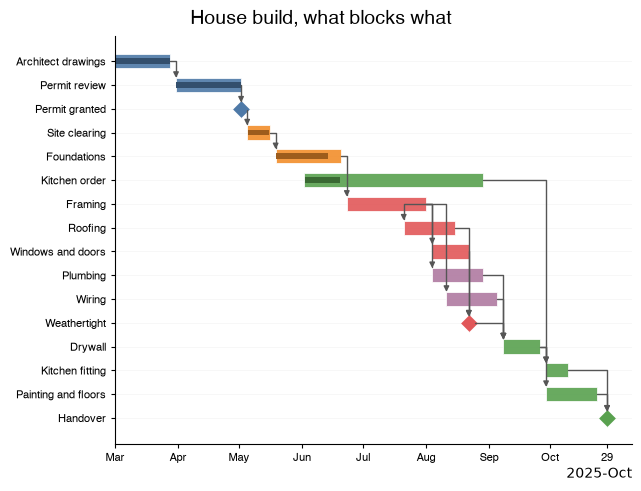

In [17]:
GanttChart(
    data=house,
    title="House build, what blocks what",
    figsize=FIG_SIZE.FULL_MEDIUM,
    sort=SORT.ASCENDING,
    # draw an arrow for every dependency
    show_dependencies=True,
    show_legend=False,
).show()

By default an arrow runs along the dependency's row and turns down onto the top of the dependent task. The `plot_gantt_dependency_entry` style attribute set to `GANTT_ARROW_ENTRY.LEFT` ([GANTT_ARROW_ENTRY](../../../references/constants/#datachart.constants.GANTT_ARROW_ENTRY)) drops the arrow from the dependency's end and enters the task from the left instead, the look of most project planning tools. A task that starts before its dependency ends leaves no room on its left and is entered from the top: the roofing, whose trusses go up while the last walls are framed.

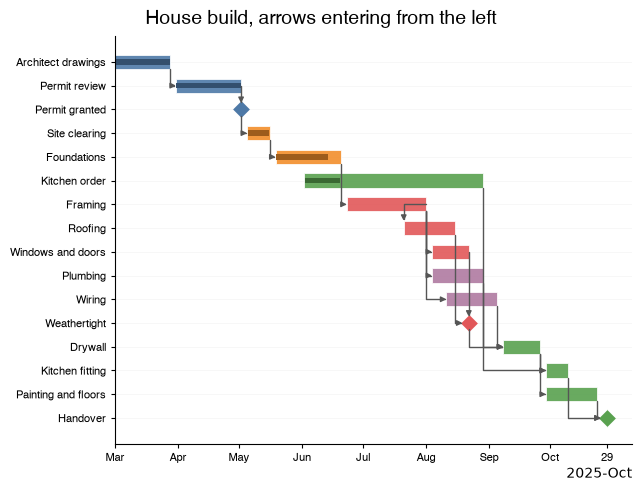

In [18]:
from datachart.constants import GANTT_ARROW_ENTRY

GanttChart(
    data=house,
    title="House build, arrows entering from the left",
    figsize=FIG_SIZE.FULL_MEDIUM,
    sort=SORT.ASCENDING,
    show_dependencies=True,
    show_legend=False,
    # enter each task from the left where there is room
    style={"plot_gantt_dependency_entry": GANTT_ARROW_ENTRY.LEFT},
).show()

### Today line

A plan is read against the present: everything left of today should be done. `show_today=True` draws a line at `today`, which is the current date unless the `today` parameter sets one (as here, so the guide renders the same every day), and `today_label` prints a label at the foot of the line. On 16 June the foundations should be nearly done, and they are at 80%; the framing starts next week.

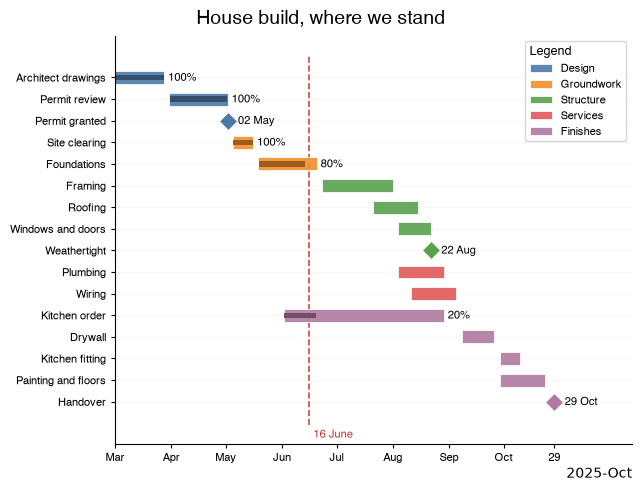

In [19]:
GanttChart(
    data=house,
    title="House build, where we stand",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_values=GANTT_VALUE.PROGRESS,
    # mark the day the project stands on
    show_today=True,
    today=TODAY,
    today_label="16 June",
).show()

### Reference lines and bands

A schedule also lives against dates it does not control: a contract date, a rainy fortnight, a holiday. `vlines` draws a vertical line at a temporal `x`, and `vspans` shades the band between a temporal `xmin` and `xmax`; each takes a dictionary or a list of them, with a `style` ([VLineSettingAttrs](../../../references/typings/#datachart.typings.VLineSettingAttrs), [VSpanSettingAttrs](../../../references/typings/#datachart.typings.VSpanSettingAttrs)). The grey band below shows where the two weeks went, and the dashed red line, the contract date, shows what they cost: the handover now lands twelve days after it. The gantt legend lists the task groups only, so the next subsection names the line and the band with notes.

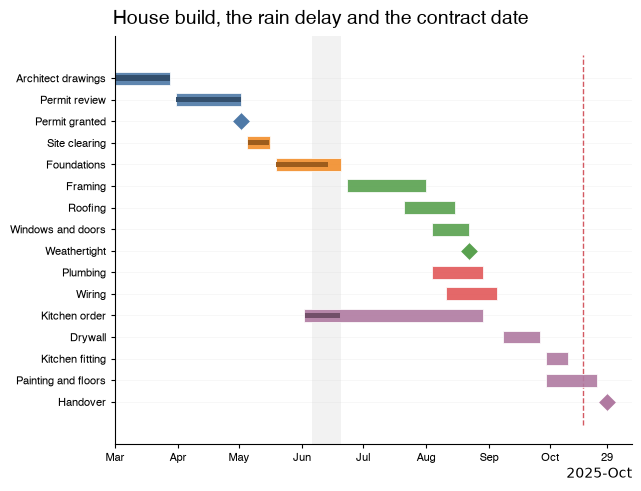

In [20]:
from datachart.constants import LINE_STYLE

GanttChart(
    data=house,
    title="House build, the rain delay and the contract date",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_legend=False,
    # the date the contract promises the house
    vlines={
        "x": CONTRACT_DATE,
        "style": {"plot_vline_color": "#c1121f", "plot_vline_style": LINE_STYLE.DASHED},
    },
    # the two weeks the rain took from the foundations
    vspans={"xmin": FOUNDATIONS["end"] - RAIN_DELAY, "xmax": FOUNDATIONS["end"]},
).show()

### Text annotations

A line marks a date; a note explains it. `texts` places text on the chart, with an optional `target` to draw a connector to a point ([TextSettingAttrs](../../../references/typings/#datachart.typings.TextSettingAttrs)); the [Text Annotations](../../utility/annotations/) guide covers placement, connectors, and styling. On a gantt chart the vertical data coordinate is the row index (the first row is `0`), and the horizontal one is a matplotlib date number, which `matplotlib.dates.date2num` converts a date into; `texts` does not take a `date` directly. Placing a note in axes fractions with `"coords": "axes"` keeps it clear of the bars. The two notes below name the band and the line of the previous chart: one points at the end of the foundations, the task that slipped, the other at the contract date on the handover's row, with a straight arrow from [ARROW_STYLE](../../../references/constants/#datachart.constants.ARROW_STYLE) set in its `style` so it runs under the bars rather than over them.

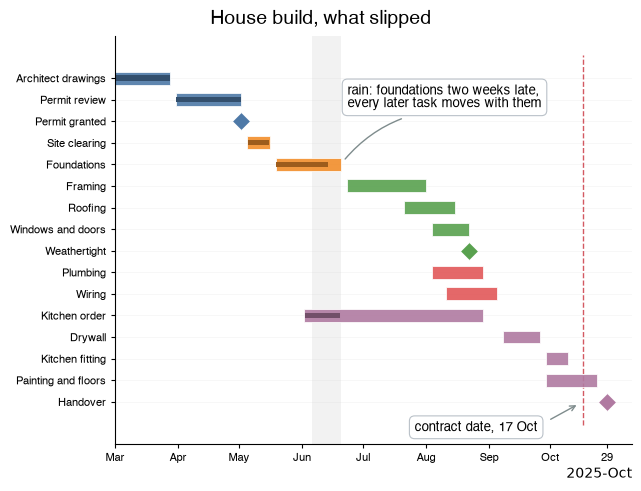

In [21]:
from matplotlib.dates import date2num
from datachart.constants import ARROW_STYLE

HANDOVER_ROW = 15

GanttChart(
    data=house,
    title="House build, what slipped",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_legend=False,
    vlines={
        "x": CONTRACT_DATE,
        "style": {"plot_vline_color": "#c1121f", "plot_vline_style": LINE_STYLE.DASHED},
    },
    vspans={"xmin": FOUNDATIONS["end"] - RAIN_DELAY, "xmax": FOUNDATIONS["end"]},
    texts=[
        # in the empty upper right, pointing at the foundations' end (row 4)
        {
            "text": "rain: foundations two weeks late,\nevery later task moves with them",
            "x": 0.45,
            "y": 0.85,
            "coords": "axes",
            "target": (date2num(FOUNDATIONS["end"]), 4),
        },
        # under the last row, a straight arrow to the contract date
        {
            "text": "contract date, 17 Oct",
            "x": 0.58,
            "y": 0.04,
            "coords": "axes",
            "target": (date2num(CONTRACT_DATE), HANDOVER_ROW),
            "style": {"plot_text_arrow_style": ARROW_STYLE.ARROW},
        },
    ],
).show()

### Gantt style

The `style` dictionary sets the look of the schedule. The bars take the bar chart's `plot_bar_*` attributes (color, alpha, edge, hatch), and the attributes specific to a gantt chart are listed in [datachart.typings.GanttStyleAttrs](../../../references/typings/#datachart.typings.GanttStyleAttrs); any attribute left out keeps the value of the active theme.

| Attribute                        | Description |
| :------------------------------- | :---------- |
| `plot_gantt_bar_height`          | The height of a task bar, as a fraction of its row. |
| `plot_gantt_progress_color`      | The color of the progress bar; `None` darkens the task bar's color. |
| `plot_gantt_progress_alpha`      | The alpha (transparency) of the progress bar. |
| `plot_gantt_progress_height`     | The height of the progress bar, as a fraction of the task bar. |
| `plot_gantt_dependency_color`    | The color of the dependency arrows. |
| `plot_gantt_dependency_width`    | The line width of the dependency arrows. |
| `plot_gantt_dependency_style`    | The arrow head, as a matplotlib arrow style such as `"-|>"` or `"->"`. |
| `plot_gantt_dependency_zorder`   | The zorder of the dependency arrows. |
| `plot_gantt_dependency_entry`    | The side a dependency arrow enters its task: `"top"` or `"left"`. |
| `plot_gantt_summary_height`      | The height of a group's summary bar under `show_group_headers`, as a fraction of its row. |
| `plot_gantt_summary_color`       | The color of the summary bars; `None` takes each group's color. |
| `plot_gantt_group_gap`           | The empty space before each group header, in rows. |
| `plot_gantt_milestone_marker`    | The marker of a milestone. |
| `plot_gantt_milestone_size`      | The size of the milestone marker, in points. |
| `plot_gantt_today_color`         | The color of the today line. |
| `plot_gantt_today_style`         | The line style of the today line. |
| `plot_gantt_today_width`         | The line width of the today line. |
| `plot_gantt_today_alpha`         | The alpha (transparency) of the today line. |

A progress report is read for the done part first, so the example below paints every task a pale grey, fills the done part at full height in a strong color, and draws light, thin arrows and a solid today line that stay out of the way.

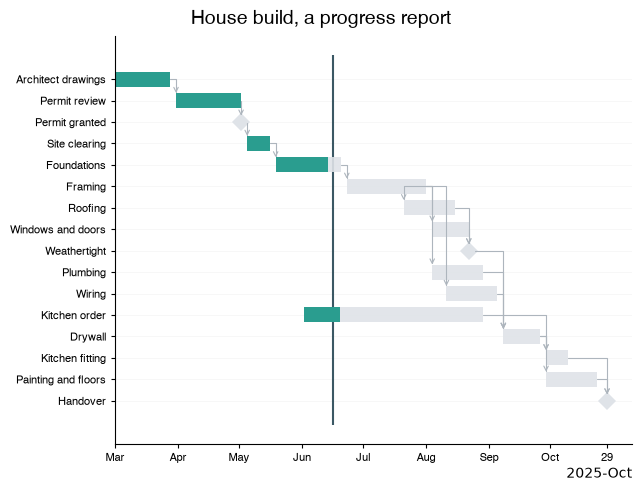

In [22]:
GanttChart(
    data=house,
    title="House build, a progress report",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_dependencies=True,
    show_today=True,
    today=TODAY,
    show_legend=False,
    style={
        # pale task bars, the done part at full height
        "plot_bar_color": "#dfe3e8",
        "plot_bar_edge_width": 0,
        "plot_gantt_bar_height": 0.7,
        "plot_gantt_progress_color": "#2a9d8f",
        "plot_gantt_progress_height": 1.0,
        # light arrows with open heads
        "plot_gantt_dependency_color": "#adb5bd",
        "plot_gantt_dependency_width": 0.8,
        "plot_gantt_dependency_style": "->",
        # a solid today line
        "plot_gantt_today_color": "#264653",
        "plot_gantt_today_style": LINE_STYLE.SOLID,
        "plot_gantt_today_width": 1.5,
    },
).show()

### Emphasis

A schedule makes a point when it shows only the tasks that matter to the question. A task record's own `"emphasis"` key takes a role from [EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS): `"highlight"` strokes the bar bolder and brings it to the front, `"background"` mutes it in the theme's muted color; a group whose every task is muted leaves the legend. Tagging the critical path, the chain of tasks with no slack, answers *which delays move the handover?* The [Highlighting](../../styling/highlighting/) guide covers emphasis across every chart type and theme.

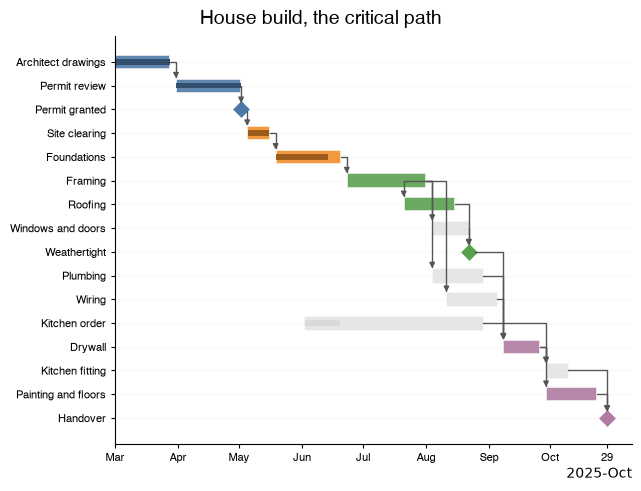

In [23]:
# the critical path highlighted, the rest muted
critical = [
    {**r, "emphasis": "highlight" if r["task"] in CRITICAL_PATH else "background"}
    for r in house
]

GanttChart(
    data=critical,
    title="House build, the critical path",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_dependencies=True,
    show_legend=False,
).show()

`emphasis_rule` picks the tasks from the data instead: it is a one-key dictionary on each task's duration in days, `{"above": v}` or `{"below": v}` (strict), `{"between": (lo, hi)}` (inclusive), `{"top": n}` or `{"bottom": n}`. The tasks that match are highlighted and the rest muted, and a record's own `"emphasis"` key wins over the rule. The tasks that run longer than a month are the ones a delay is most likely to hit:

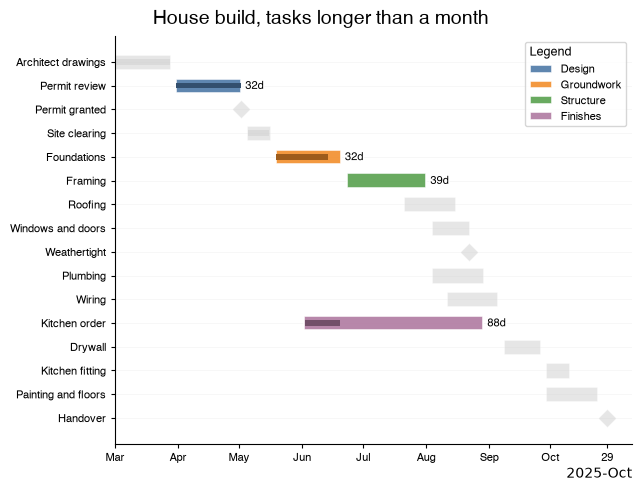

In [24]:
GanttChart(
    data=house,
    title="House build, tasks longer than a month",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_values=GANTT_VALUE.DURATION,
    xmax=date(2025, 11, 10),
    # highlight the tasks longer than 30 days
    emphasis_rule={"above": 30},
).show()

## Multiple Gantt Charts

*Where did the plan go wrong?* is answered by setting the plan beside the forecast. A list of lists in `data` draws one schedule per subplot, one per row unless `max_cols` sets more columns, and the per-schedule parameters (`subtitle`, `style`, `emphasis`) become lists aligned with it. The whole-schedule `emphasis` mutes the signed plan, so the eye goes to the forecast, where every task from the foundations on sits two weeks later.

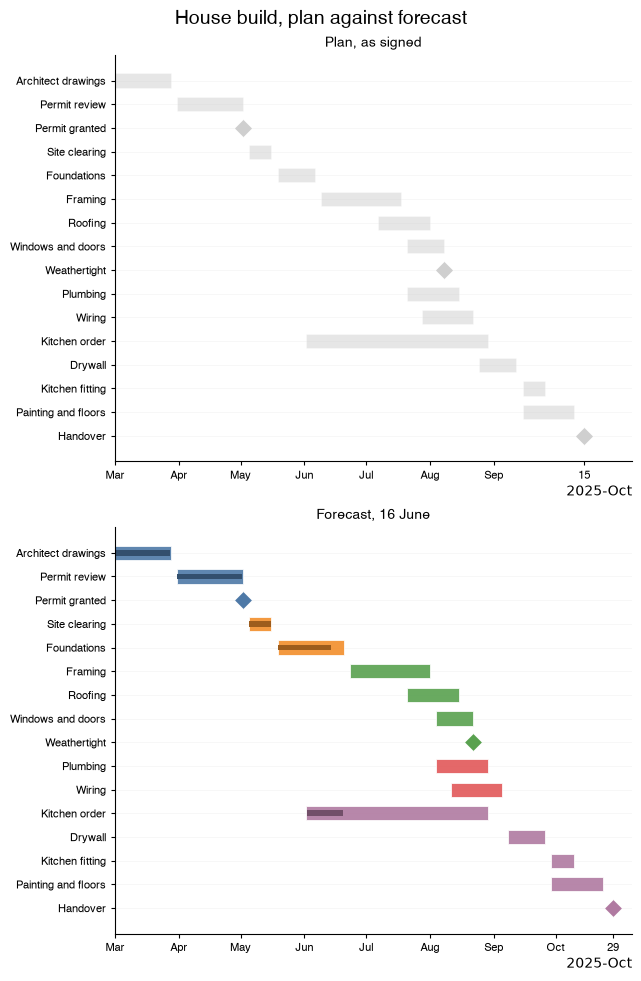

In [25]:
GanttChart(
    # the signed plan and the current forecast
    data=[baseline, house],
    subtitle=["Plan, as signed", "Forecast, 16 June"],
    title="House build, plan against forecast",
    figsize=FIG_SIZE.A4_PORTRAIT,
    # one schedule per row, on one date window
    max_cols=1,
    xmin=date(2025, 3, 1),
    xmax=date(2025, 11, 7),
    # the plan is context, the forecast is the point
    emphasis=["background", None],
    show_legend=False,
).show()

### Composing gantt charts

A gantt chart draws time along one axis and tasks down the other, so there is no shared coordinate space to overlay another chart on: [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) rejects a gantt figure. [datachart.utils.Grid](../../../references/utils/#datachart.utils.Grid) arranges it beside other charts, each in its own cell ([Grid](../../utility/grid/) guide). The example sets the schedule over a bar chart of the task days each trade books, the number a builder prices the job by.

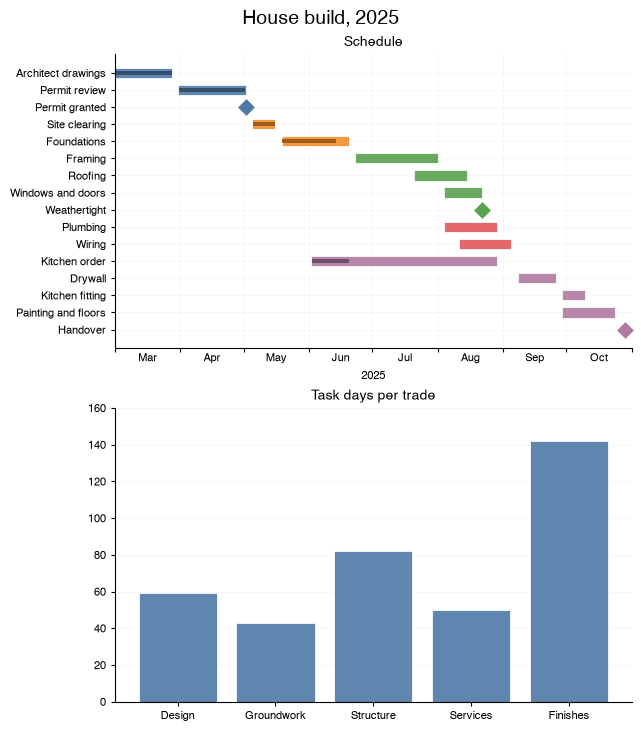

In [26]:
from datachart.charts import BarChart
from datachart.utils import Grid

trades = list(dict.fromkeys(r["group"] for r in house))
task_days = [
    {"label": trade, "y": sum((r["end"] - r["start"]).days for r in house if r["group"] == trade)}
    for trade in trades
]

schedule = GanttChart(data=house, title="Schedule", show_legend=False, period=GANTT_DATE_PERIOD.MONTH)
effort = BarChart(data=task_days, title="Task days per trade", show_grid=SHOW_GRID.Y, ymin=0)

Grid([[schedule], [effort]], title="House build, 2025", figsize=FIG_SIZE.FULL_TALL).show()

## Additional Features

### Other date types

Records often come from a file or a database rather than from `datetime` code. `start` and `end` accept any temporal type: `numpy.datetime64` values, as numpy reads dates from a CSV file, pandas `Timestamp` values, as a data frame holds them, and `datetime.datetime` values, which place a bar's ends at a time of day. Date strings are never parsed, so a column of strings has to be converted first. `curing`, defined in a hidden cell, is the illustrative plan for the four weeks after the foundation slab is poured, written as `numpy.datetime64` days: the slab is kept moist for a week while it gains strength, and test cubes are crushed at 7 and 28 days to check that the concrete reaches it.

In [27]:
import numpy as np

# an illustrative curing plan for the foundation slab: (task, start, end) as numpy dates
CURING = [
    ("Pour slab", "2025-06-18", "2025-06-19"),
    ("Keep slab moist", "2025-06-19", "2025-06-26"),
    ("7-day cube test", "2025-06-25", "2025-06-25"),
    ("Slab gains strength", "2025-06-19", "2025-07-16"),
    ("28-day cube test", "2025-07-16", "2025-07-16"),
]
curing = [
    {"task": task, "start": np.datetime64(start), "end": np.datetime64(end)}
    for task, start, end in CURING
]

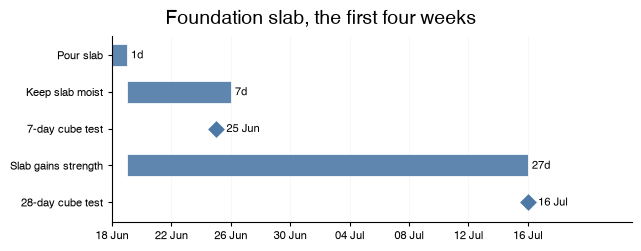

In [28]:
GanttChart(
    data=curing,
    title="Foundation slab, the first four weeks",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.X,
    show_values=GANTT_VALUE.DURATION,
    xmax=date(2025, 7, 23),
    # print the ticks as day and month
    xticks_format="%d %b",
).show()

### Themes

A theme sets the palette, the fonts, and the bar, arrow, and today-line styles of every chart at once; themes that tell series apart by hatching give each task group its own hatch, which keeps a printed plan readable in black and white. Apply one with [datachart.config.Config.set_theme](../../../references/config/#datachart.config.Config.set_theme) as the [Themes](../../styling/themes/) guide shows; the [Theme Gallery](../../styling/theme-gallery/) shows the whole suite under each theme. Style is resolved when the chart is created, so a theme set before the call and reset after it applies to that chart alone.

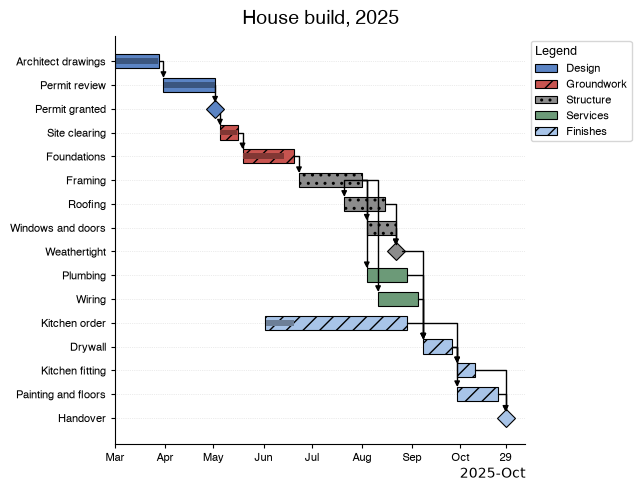

In [29]:
from datachart.config import config
from datachart.constants import THEME

config.set_theme(THEME.HATCH)
figure = GanttChart(
    data=house,
    title="House build, 2025",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_dependencies=True,
    legend={"location": LEGEND_LOCATION.OUTSIDE_RIGHT},
)
config.set_theme(THEME.DEFAULT)
figure.show()

## Real-World Examples

The examples below put the features above to work on three schedules, each one answering a planning question. The schedules are illustrative, written out in hidden cells with the shape real ones take; each example says what its data stands for.

### Example 1: Will the Sprint Finish on Time? (Day Periods, Progress Labels, and the Today Line)

`sprint` holds the tickets of an illustrative two-week sprint of an app team, Monday 1 to Friday 12 September 2025, with each ticket's `progress` as the board shows it on the morning of Thursday 11 September, `SPRINT_TODAY`. A ticket's `end` is the morning after its last working day, so a ticket worked on Monday and Tuesday ends on Wednesday and fills the Monday and Tuesday columns. The question is which tickets are behind: any ticket whose end has passed and whose progress is short of 100%. Day periods give the board its columns, the weekend is shaded, progress labels print the numbers, the today line marks the morning, and the late tickets carry a `"highlight"` role while the rest are muted (a muted ticket prints no label), so the eye lands on the two tickets to chase in the stand-up. A milestone on Saturday morning marks the end of the sprint.

In [30]:
SPRINT_TODAY = date(2025, 9, 11)

# an illustrative sprint board: (ticket, team, first day, morning after the last day, progress)
SPRINT = [
    ("Sign-in API", "Backend", date(2025, 9, 1), date(2025, 9, 4), 1.0),
    ("Password reset API", "Backend", date(2025, 9, 3), date(2025, 9, 10), 0.8),
    ("Push notifications", "Backend", date(2025, 9, 8), date(2025, 9, 13), 0.5),
    ("Sign-in screen", "App", date(2025, 9, 1), date(2025, 9, 6), 1.0),
    ("Reset password screen", "App", date(2025, 9, 8), date(2025, 9, 11), 0.5),
    ("Settings page", "App", date(2025, 9, 9), date(2025, 9, 13), 0.4),
    ("Test plan", "QA", date(2025, 9, 2), date(2025, 9, 4), 1.0),
    ("End-to-end tests", "QA", date(2025, 9, 10), date(2025, 9, 13), 0.2),
]


def board_role(end, progress):
    # late: due before today and not finished
    return "highlight" if end <= SPRINT_TODAY and progress < 1 else "background"


sprint = [
    {"task": t, "group": g, "start": s, "end": e, "progress": p, "emphasis": board_role(e, p)}
    for t, g, s, e, p in SPRINT
]
sprint.append({"task": "Sprint end", "start": date(2025, 9, 13), "end": date(2025, 9, 13)})

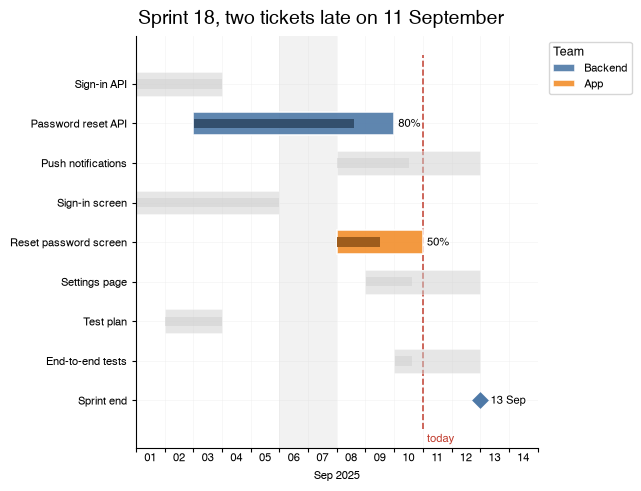

In [31]:
GanttChart(
    data=sprint,
    title="Sprint 18, two tickets late on 11 September",
    figsize=FIG_SIZE.FULL_MEDIUM,
    # one column per day, under its month
    period=GANTT_DATE_PERIOD.DAY,
    xmin=date(2025, 9, 1),
    xmax=date(2025, 9, 15),
    # the weekend
    vspans={"xmin": date(2025, 9, 6), "xmax": date(2025, 9, 8)},
    show_values=GANTT_VALUE.PROGRESS,
    show_today=True,
    today=SPRINT_TODAY,
    today_label="today",
    legend={"title": "Team", "location": LEGEND_LOCATION.OUTSIDE_RIGHT},
).show()

### Example 2: What Does the Grant Deliver, and When? (Quarters, Group Headers, Milestones, and Dependencies)

`grant` holds the work plan of an illustrative three-year research grant, January 2026 to December 2028, in the layout funders ask for: work packages (WP1 to WP4) as groups, their tasks, and the milestones the reviewers check. A task runs from the first day of its first project month to the first day of the month after its last, which the hidden cell's `month(n)` helper computes. The reviewer's questions are *what is delivered in which year, and what depends on what?* Quarters under their years give the columns a funder reports in, group headers show how long each work package runs, the milestones mark the review points, a dotted line marks the mid-term review in July 2027, and the dependency arrows, entering from the left, show that the pilot study hangs on the validated model.

In [32]:
def month(n):
    # the first day of project month n, counted from January 2026
    return date(2026 + (n - 1) // 12, (n - 1) % 12 + 1, 1)


# an illustrative work plan: (task, work package, first month, last month, depends on)
WORK_PLAN = [
    ("Project management", "WP1 Management", 1, 36, []),
    ("Data collection", "WP2 Data", 1, 12, []),
    ("Open dataset", "WP2 Data", 13, 13, ["Data collection"]),
    ("Model design", "WP3 Methods", 7, 18, ["Data collection"]),
    ("Model validation", "WP3 Methods", 19, 27, ["Model design"]),
    ("Validated model", "WP3 Methods", 28, 28, ["Model validation"]),
    ("Pilot study", "WP4 Impact", 28, 34, ["Validated model"]),
    ("Open toolkit", "WP4 Impact", 25, 36, ["Model design"]),
    ("Final report", "WP4 Impact", 37, 37, ["Pilot study", "Open toolkit"]),
]
grant = [
    {
        "task": task,
        "group": package,
        "start": month(first),
        # a milestone falls on the first day of its month
        "end": month(first) if first == last else month(last + 1),
        "depends_on": depends_on,
    }
    for task, package, first, last, depends_on in WORK_PLAN
]

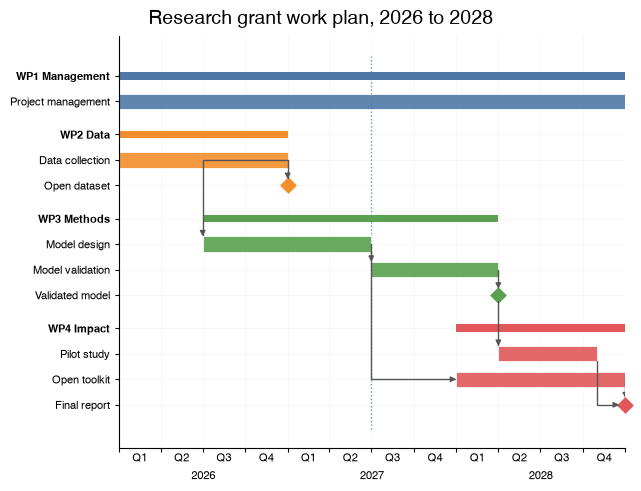

In [33]:
GanttChart(
    data=grant,
    title="Research grant work plan, 2026 to 2028",
    figsize=FIG_SIZE.FULL_MEDIUM,
    # quarters under their years
    period=GANTT_DATE_PERIOD.QUARTER,
    xmin=date(2026, 1, 1),
    xmax=date(2029, 1, 1),
    show_group_headers=True,
    show_dependencies=True,
    style={
        "plot_gantt_dependency_entry": GANTT_ARROW_ENTRY.LEFT,
        "plot_gantt_group_gap": 0.3,
    },
    # the mid-term review
    vlines={"x": date(2027, 7, 1), "style": {"plot_vline_style": LINE_STYLE.DOTTED}},
).show()

### Example 3: Which Team Is Holding Up the Launch? (Two Schedules, a Shared Window, a Note, and a Grid)

An illustrative app launch on Monday 1 December 2025 depends on two teams. `platform` holds the platform team's tasks and `mobile` the mobile team's, as forecast on Monday 3 November, `LAUNCH_TODAY`. The tasks that end after the launch date carry a `"highlight"` role and the rest are muted, so a team whose chart is all grey is on time. The question is which team puts the launch date at risk. Each team's schedule is its own `GanttChart` with the same date window, the same today line, and a launch line, so [Grid](../../utility/grid/) can stack them and the dates line up down the page. The platform team is on time; the mobile team's app store review ends after the launch, and a note on its chart says so.

In [34]:
LAUNCH = date(2025, 12, 1)
LAUNCH_TODAY = date(2025, 11, 3)

# an illustrative launch: (task, start, end) per team
PLATFORM = [
    ("Payments service", date(2025, 9, 29), date(2025, 10, 31)),
    ("Load testing", date(2025, 10, 27), date(2025, 11, 14)),
    ("Security audit", date(2025, 11, 3), date(2025, 11, 21)),
    ("Production release", date(2025, 11, 24), date(2025, 11, 26)),
]
MOBILE = [
    ("Checkout screens", date(2025, 9, 29), date(2025, 11, 7)),
    ("Beta testing", date(2025, 11, 3), date(2025, 11, 21)),
    ("App store review", date(2025, 11, 21), date(2025, 12, 5)),
]


def team_schedule(rows):
    # past the launch date: the risk to show; the rest muted
    return [
        {"task": task, "start": start, "end": end, "emphasis": "highlight" if end > LAUNCH else "background"}
        for task, start, end in rows
    ]


platform = team_schedule(PLATFORM)
mobile = team_schedule(MOBILE)

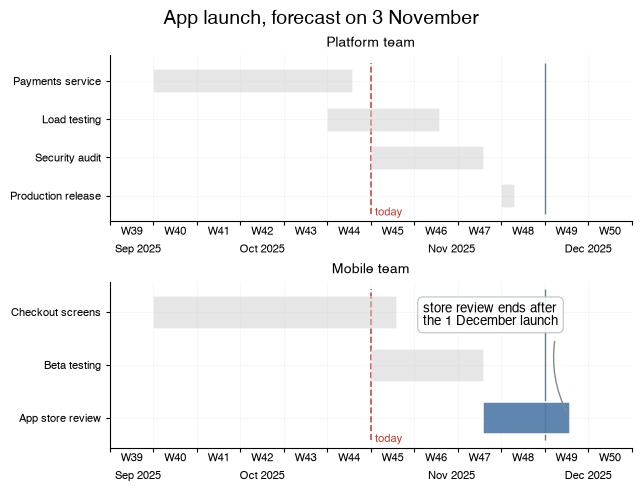

In [35]:
def launch_schedule(data, team, **kwargs):
    # one team's forecast, on the shared window with the today and launch lines
    return GanttChart(
        data=data,
        title=team,
        xmin=date(2025, 9, 22),
        xmax=date(2025, 12, 15),
        period=GANTT_DATE_PERIOD.WEEK,
        show_today=True,
        today=LAUNCH_TODAY,
        today_label="today",
        # the launch date, solid and dark
        vlines={"x": LAUNCH, "style": {"plot_vline_color": "#264653", "plot_vline_style": LINE_STYLE.SOLID}},
        **kwargs,
    )


review_end = MOBILE[2][2]
Grid(
    [
        [launch_schedule(platform, "Platform team")],
        [
            launch_schedule(
                mobile,
                "Mobile team",
                # a note in the empty upper right, pointing at the review's end
                texts={
                    "text": "store review ends after\nthe 1 December launch",
                    "x": 0.6,
                    "y": 0.8,
                    "coords": "axes",
                    "target": (date2num(review_end), 2),
                },
            )
        ],
    ],
    title="App launch, forecast on 3 November",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()